# Chapter 17: QAE

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [ ]:
# Setup and imports
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler 
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from Chapter03_EngineeringProblems_functions import (truss2x2,truss2x3,truss3x3)

from Chapter15_QAE_functions import  build_grover_operator, build_observable_circuit

ModuleNotFoundError: No module named 'qiskit_algorithms'

## QAE Motivation: Geometry calcuations

### Area calculations

1.5 1


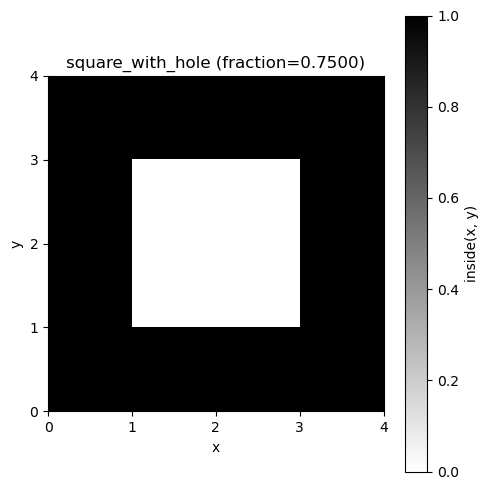

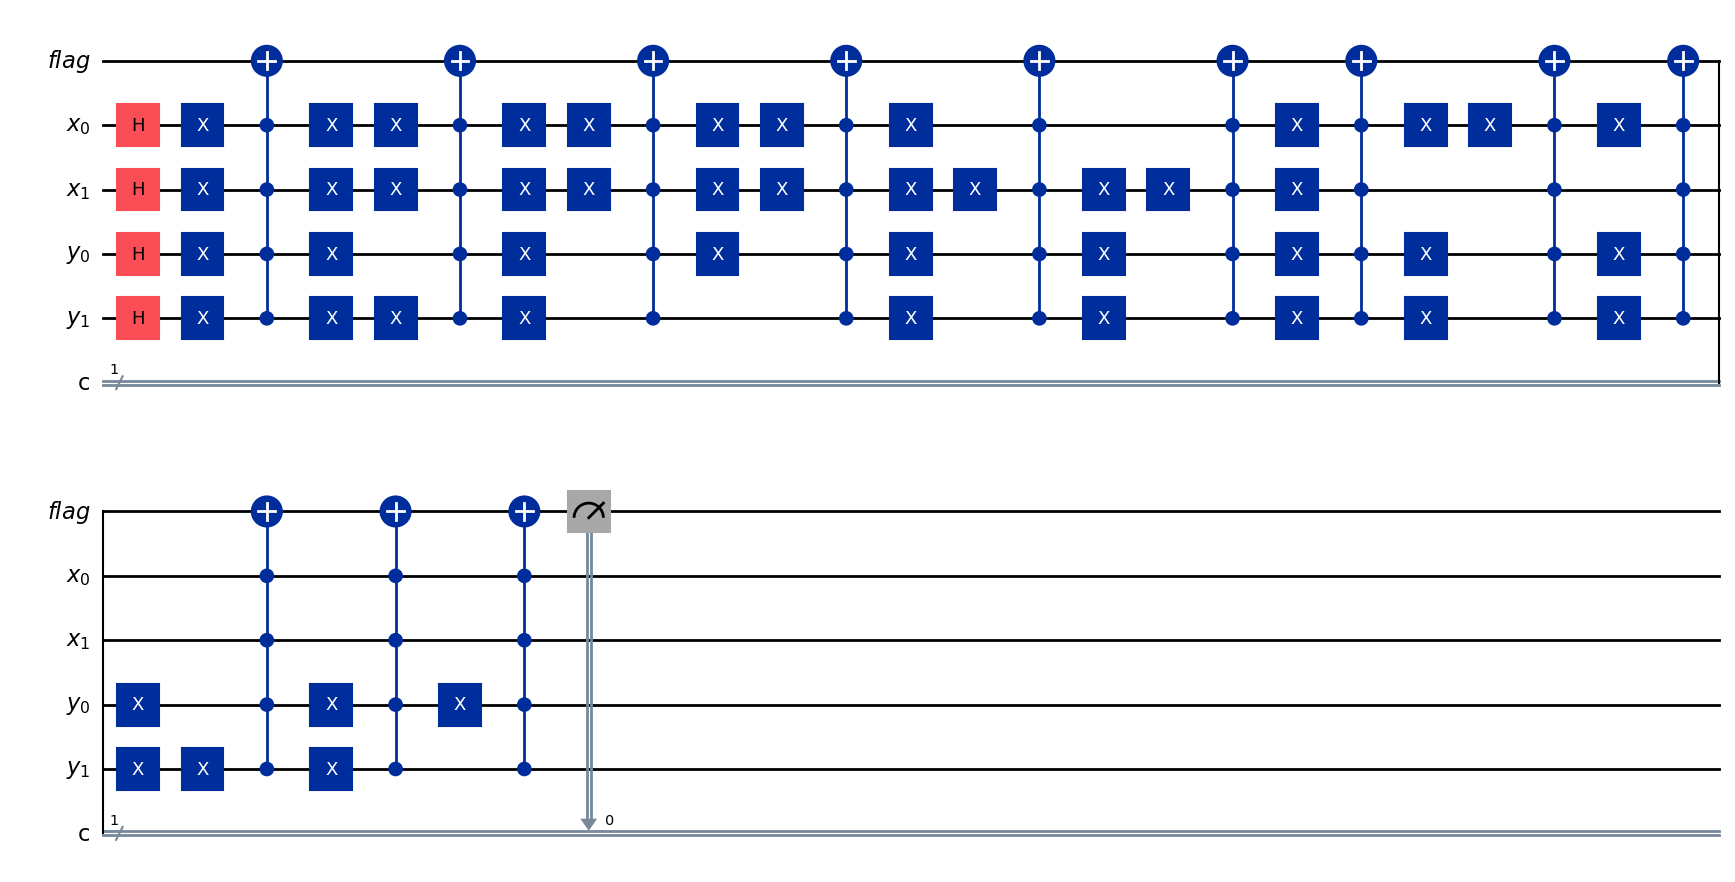

estimated area fraction: 0.8400
true  area fraction:     0.7500   (= 12/16)
sampling error:          0.0900   (~ 1/sqrt(shots) = 0.0224)


In [ ]:
from Chapter15_QAE_functions import (
    region_oracle, region_area,
    disk_predicate, square_with_hole_predicate, annulus_predicate,
    estimate_area,
)

m = 2
N = 1 << m
c = N // 2 - 0.5
r = N //3
print(c, r  )
example = "square_with_hole"
if example == "disk":
    predicate = disk_predicate(c, c, r)
elif example == "square_with_hole":
    predicate = square_with_hole_predicate(c, c, r)
elif example == "annulus":
    predicate = annulus_predicate(c, c, 3, 5)
else:
    raise ValueError(f"unknown example: {example}")

oracle, regs = region_oracle(m, predicate)     # one predicate -> the oracle
inside       = region_area(m, predicate)        # same predicate -> the true count
a_true       = inside / (N * N)


mask = np.array([[predicate(i, j) for j in range(N)] for i in range(N)])

plt.figure(figsize=(5, 5))
plt.imshow(
    mask.astype(int).T,
    origin="lower",
    cmap="gray_r",
    interpolation="nearest",
    extent=[0, N, 0, N],  # x,y axes start at 0
)
plt.xlim(0, N)
plt.ylim(0, N)
plt.xticks(range(0, N + 1))
plt.yticks(range(0, N + 1))
plt.colorbar(label="inside(x, y)")
plt.title(f"{example} (fraction={mask.mean():.4f})")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()
a_hat, counts,circ = estimate_area(oracle, regs, shots=100)

display(circ.draw('mpl'))
print(f"estimated area fraction: {a_hat:.4f}")
a_true = np.sum(mask) / (N * N)
print(f"true  area fraction:     {a_true:.4f}   (= {np.sum(mask)}/{N*N})")
print(f"sampling error:          {abs(a_hat - a_true):.4f}   (~ 1/sqrt(shots) = {1/np.sqrt(2000):.4f})")

### Centroid

In [ ]:
from Chapter15_QAE_functions import quantum_centroid

[x_centroid, y_centroid], area = quantum_centroid(m, predicate, shots=2000)
print(f"estimated centroid: ({x_centroid:.2f}, {y_centroid:.2f})")
print(f"area: {area:.2f}")

estimated centroid: (1.50, 1.47)
area: 0.76


### Scaling

In [ ]:
from Chapter15_QAE_functions import sampling_scaling

print("This will take couple of minutes to run...")

shot_list = [100, 300, 1000, 3000, 10000]
rows, rms_errors, predicted = sampling_scaling(oracle, regs, shot_list, a_true, trials=20)


print(f"{'shots':>8} {'RMS error':>12} {'predicted':>12} {'ratio':>8}")
print("-" * 44)
for shots, rms, pred in rows:
    print(f"{shots:>8} {rms:>12.5f} {pred:>12.5f} {rms/pred:>8.2f}")

# log-log plot: a straight line of slope -1/2 is the signature
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(shot_list, rms_errors, 'o-', color='steelblue',
            label='observed RMS error')
ax.loglog(shot_list, predicted, '--', color='firebrick',
            label=r'$\sqrt{a(1-a)/n}$')
ax.set_xlabel('oracle queries (= shots)', fontsize=12)
ax.set_ylabel('error in area fraction', fontsize=12)
ax.set_title(r'Naive estimation: error $\sim 1/\sqrt{n}$', fontsize=13)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()




In [ ]:
beta   = np.pi / 6
a_true = np.sin(beta)**2   # 0.25

epsilon_target = 0.001
# State preparation: A = R_y(2 beta)
A = QuantumCircuit(1)
A.ry(2*beta, 0)

# Good state = |1> on qubit 0
problem = EstimationProblem(state_preparation=A, objective_qubits=[0])

# Target precision 0.01 on a, 95% confidence
iqae = IterativeAmplitudeEstimation(epsilon_target=epsilon_target,alpha=0.05,sampler=StatevectorSampler())
result = iqae.estimate(problem)

print(f"True a:            {a_true:.4f}")
print(f"IQAE estimate:     {result.estimation:.4f}")
print(f"95% CI:            [{result.confidence_interval[0]:.4f}, "
      f"{result.confidence_interval[1]:.4f}]")
print(f"Oracle queries:    {result.num_oracle_queries}")
print(f"k schedule:        {result.powers}")

### Observable

In [ ]:
# --- Problem definition ---
f = np.array([1., 0., 0.5, 0.2])
f = f / np.linalg.norm(f)
A_mat = np.array([[ 1.,  0.,  0., -0.5],
                  [ 0.,  1.,  0.,  0. ],
                  [ 0.,  0.,  1.,  0. ],
                  [-0.5, 0.,  0.,  1. ]])
x_vec     = np.array([0.6, 0.8, 0., 0.])
classical = np.abs(f @ A_mat @ x_vec)

# --- Build circuit ---
A_obs, metadata = build_observable_circuit(A_mat, x_vec, f)
alpha_lcu  = metadata['alpha']
p_succ     = metadata['p_success']
good_qubits = metadata['good_qubits']

# --- Statevector diagnostics ---
num_anc = metadata['num_ancilla']
num_sys = metadata['num_system']
sv = Statevector(A_obs)
probs = sv.probabilities_dict()


# --- Run IQAE ---
problem = EstimationProblem(state_preparation=A_obs, objective_qubits=good_qubits)
iqae    = IterativeAmplitudeEstimation(epsilon_target=0.01, alpha=0.05,
                                       sampler=StatevectorSampler())
result  = iqae.estimate(problem)

a_hat, (a_lo, a_hi) = result.estimation, result.confidence_interval

# --- Recovery formula ---
obs_hat = np.sqrt(a_hat) * alpha_lcu * np.sqrt(p_succ)
obs_lo  = np.sqrt(a_lo)  * alpha_lcu * np.sqrt(p_succ)
obs_hi  = np.sqrt(a_hi)  * alpha_lcu * np.sqrt(p_succ)

print("=== Results ===")
print(f"Classical:           {classical:.4f}")
print(f"IQAE estimate:       {obs_hat:.4f}")
print(f"95% CI:              [{obs_lo:.4f}, {obs_hi:.4f}]")
print(f"Oracle queries:      {result.num_oracle_queries}")
print(f"k schedule:        {result.powers}")
